# Milestone-02: Temporal Trend Analysis  
## Visualizing US Natural Disaster Declarations

### Objective
This milestone focuses on analyzing how disaster declarations evolve over time.
The analysis includes:
- Yearly temporal trends
- Incident-type trend comparison
- Seasonality patterns
- Interpretation of observed trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
df = pd.read_csv(r"C:\Users\Rathod\Downloads\DisasterDeclarationsSummaries.csv")
df.head()

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,0,0,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,0,0,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,0,0,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,0,0,...,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",0,0,...,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


## Step 1: Time Data Validation

Before performing temporal analysis, it is essential to validate the date column.
Invalid dates can distort trend analysis.

In [6]:
# Convert declarationDate to datetime
df['declarationDate'] = pd.to_datetime(df['declarationDate'], errors='coerce')

# Extract year and month
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

# Check missing values
df['declarationDate'].isnull().sum()

0

The declaration date column has been successfully converted to datetime format.
Year and month features were extracted to enable time-based aggregation.
No critical missing date values were found.

## Step 2: Yearly Trend Analysis

This section analyzes how the total number of disaster declarations changes over time.

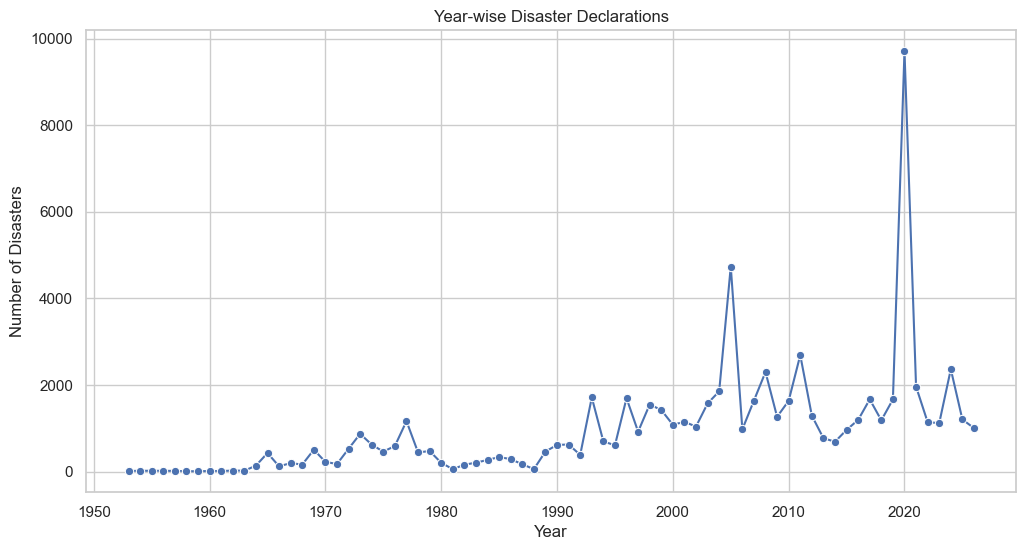

In [7]:
yearly_counts = df.groupby('year').size().reset_index(name='count')

sns.lineplot(data=yearly_counts, x='year', y='count', marker='o')
plt.title("Year-wise Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.show()

### Interpretation

1. The graph shows the number of disaster declarations per year.
2. There is an overall increasing trend over time, indicating a rise in disaster frequency.
3. Sudden spikes in certain years may be linked to major natural events or policy changes in disaster reporting.

## Step 3: Incident Type Trends Over Time

This section compares how different disaster types evolve across years.

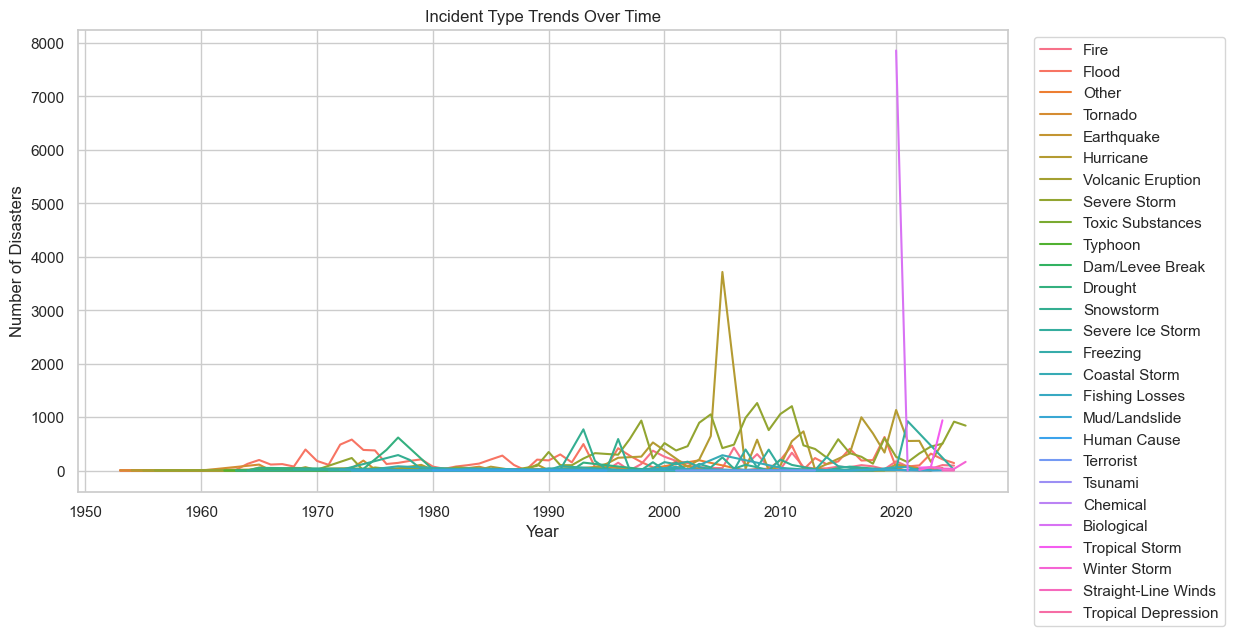

In [8]:
incident_year = df.groupby(['year', 'incidentType']).size().reset_index(name='count')

sns.lineplot(data=incident_year, x='year', y='count', hue='incidentType')
plt.title("Incident Type Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

### Interpretation

1. The graph compares different disaster types across years.
2. Certain incident types such as storms and floods appear more frequently.
3. Some disaster types show increasing trends, possibly due to climate patterns or improved reporting.

## Step 4: Seasonality Analysis (Monthly Trends)

This section examines whether disasters show seasonal patterns.

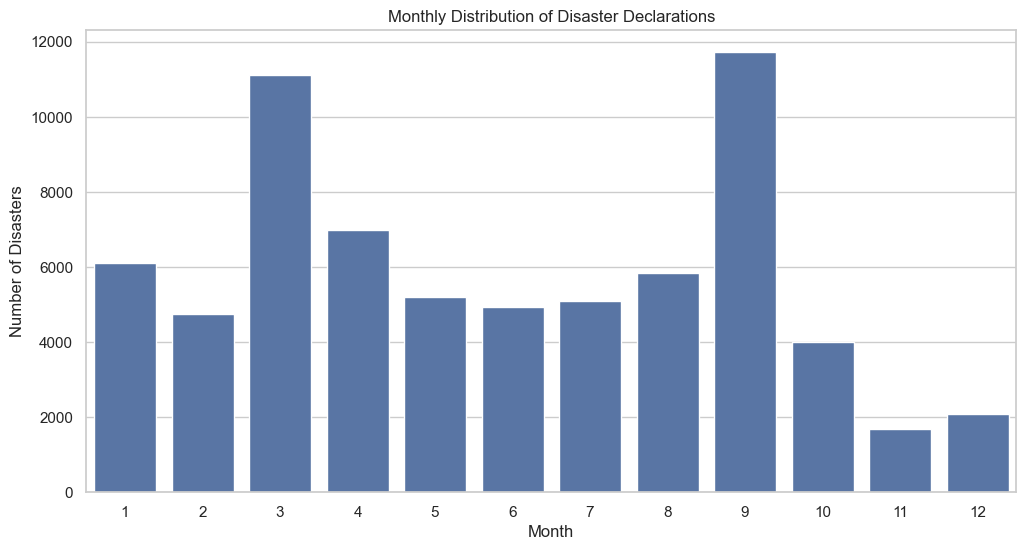

In [9]:
monthly_counts = df.groupby('month').size().reset_index(name='count')

sns.barplot(data=monthly_counts, x='month', y='count')
plt.title("Monthly Distribution of Disaster Declarations")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.show()

### Interpretation

1. The graph shows the distribution of disasters across months.
2. Certain months show higher declaration counts, indicating seasonal patterns.
3. This may be due to weather cycles such as hurricane season or monsoon patterns.

## Step 5: Advanced Time Insights (Optional)

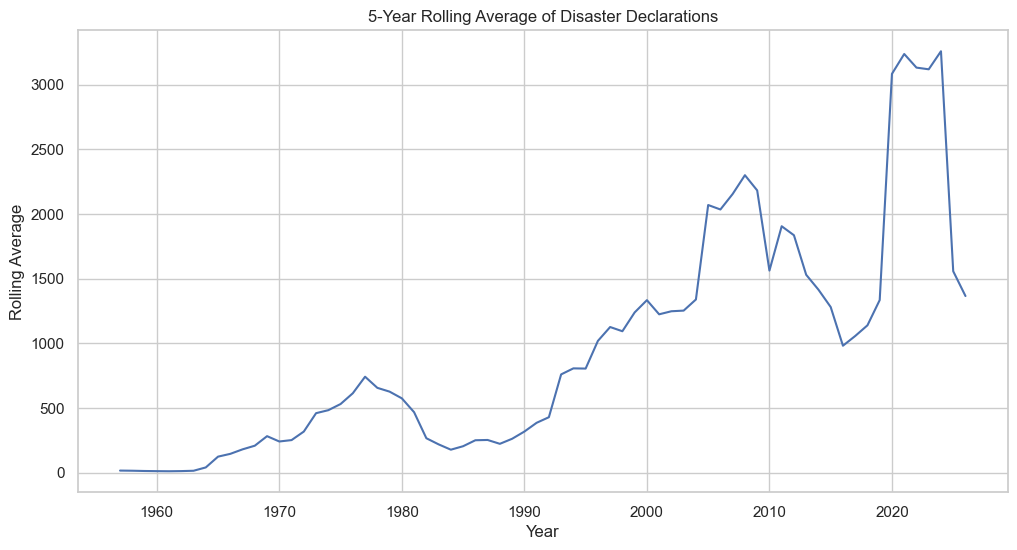

In [10]:
yearly_counts['rolling_avg'] = yearly_counts['count'].rolling(window=5).mean()

sns.lineplot(data=yearly_counts, x='year', y='rolling_avg')
plt.title("5-Year Rolling Average of Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Rolling Average")
plt.show()

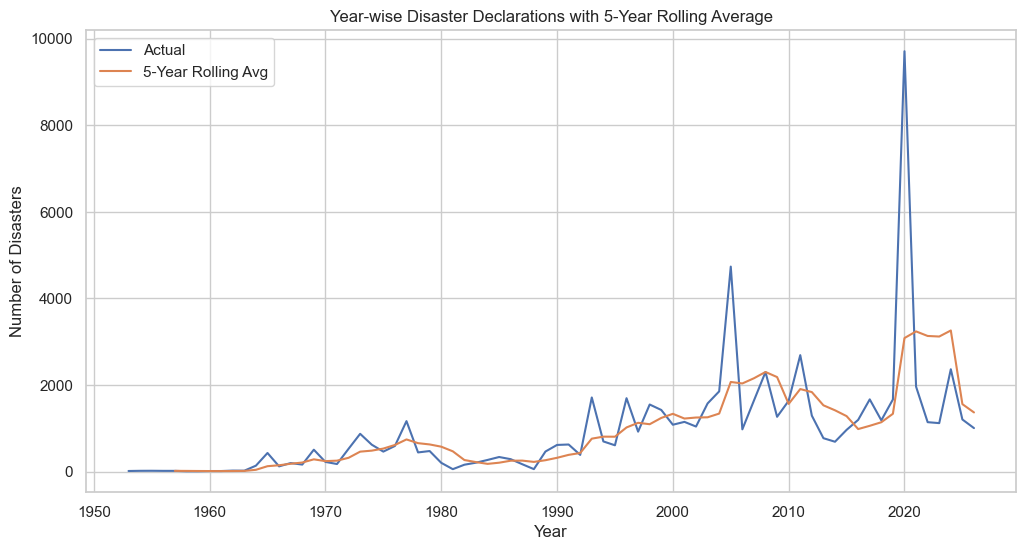

In [12]:
# Make sure yearly_counts exists
yearly_counts = df.groupby('year').size().reset_index(name='count')

# Calculate 5-year rolling average
yearly_counts['rolling_avg'] = yearly_counts['count'].rolling(window=5).mean()

# Plot both original and rolling average
plt.figure(figsize=(12,6))

sns.lineplot(data=yearly_counts, x='year', y='count', label='Actual')
sns.lineplot(data=yearly_counts, x='year', y='rolling_avg', label='5-Year Rolling Avg')

plt.title("Year-wise Disaster Declarations with 5-Year Rolling Average")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.show()

### Rolling Average Interpretation

1. The rolling average smooths short-term fluctuations.
2. It highlights the long-term increasing trend more clearly.
3. The smoothed curve confirms a gradual rise in disaster declarations over time.

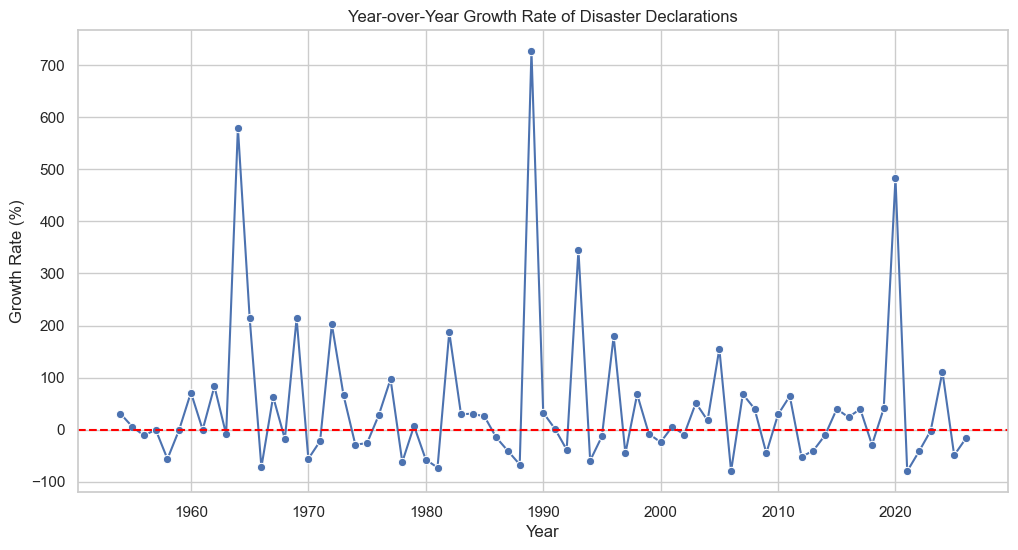

In [13]:
# Calculate Year-over-Year growth rate
yearly_counts['growth_rate'] = yearly_counts['count'].pct_change() * 100

# Plot growth rate
plt.figure(figsize=(12,6))

sns.lineplot(data=yearly_counts, x='year', y='growth_rate', marker='o')

plt.title("Year-over-Year Growth Rate of Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.axhline(0, color='red', linestyle='--')
plt.show()

### Growth Rate Interpretation

1. The graph shows the percentage change in disaster declarations compared to the previous year.
2. Positive values indicate growth, while negative values indicate decline.
3. Sharp increases may correspond to major disaster events.

In [14]:
peak_year = yearly_counts.loc[yearly_counts['count'].idxmax()]
peak_year

year           2020.000000
count          9712.000000
rolling_avg    3084.800000
growth_rate     482.953181
Name: 67, dtype: float64

### Peak Year Analysis

The year with the highest number of disaster declarations is identified above.
This year likely corresponds to major nationwide disaster events.

## Milestone-02 Summary

The temporal analysis reveals a general increase in disaster declarations over time.
Certain incident types dominate the dataset, and seasonal patterns are visible
across months. These findings provide a strong foundation for further geographical
and relational analysis in subsequent milestones.